<a href="https://colab.research.google.com/github/montalvoB/Seizure-Classifcation-LSTM/blob/main/chbmit_lstm_xai_5fold_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Colab setup and common imports
try:
    import shap
    import lime
except ModuleNotFoundError:
    !pip -q install shap lime

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

base = '/content/drive/MyDrive/MIT EEG Dataset/'

train_data = torch.load(base + 'train_z_score_norm.pt', map_location=device)
val_data   = torch.load(base + 'val_z_score_norm.pt',   map_location=device)
test_data  = torch.load(base + 'test_z_score_norm.pt',  map_location=device)


In [ ]:
print(train_data.keys())
print(train_data['X'].shape)  # expect (3306, 18, 1280)
print(train_data['y'].shape)  # expect (3306,)
print(train_data['y'].unique())  # expect tensor([0, 1])

dict_keys(['X', 'y', 'patient_ids', 'norm'])
torch.Size([3306, 18, 1280])
torch.Size([3306])
tensor([0, 1], device='cuda:0')


In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

# ── Dataset ───────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, data):
        self.X = data['X']
        self.y = data['y']

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Stored tensors are (channels, time); LSTM expects (time, channels).
        return self.X[idx].T, self.y[idx]

# ── Combine train + validation for 5-fold cross-validation ───────────────────
# The original test split is kept untouched for final held-out reporting/XAI.
cv_data = {
    'X': torch.cat([train_data['X'], val_data['X']], dim=0),
    'y': torch.cat([train_data['y'], val_data['y']], dim=0),
}

cv_dataset = EEGDataset(cv_data)
test_dataset = EEGDataset(test_data)

def make_loader(dataset, batch_size=32, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

test_loader = make_loader(test_dataset, batch_size=32, shuffle=False)

# Backward-compatible loaders used by the XAI cells below.
# These are not used for model selection anymore.
train_loader = make_loader(EEGDataset(train_data), batch_size=32, shuffle=True)
val_loader   = make_loader(EEGDataset(val_data),   batch_size=32, shuffle=False)

INPUT_SIZE = cv_data['X'].shape[1]  # 18 EEG channels
print(f"CV samples: {len(cv_dataset)} | Test samples: {len(test_dataset)} | Input size: {INPUT_SIZE}")


CV samples: 3854 | Test samples: 468 | Input size: 18


In [ ]:
import itertools
import copy
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    auc
)
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

# ── 5-Fold CV Settings ────────────────────────────────────────────────────────
N_SPLITS = 5
BATCH_SIZE = 32
RANDOM_STATE = 42

# ── Reduced Hyperparameter Grid ───────────────────────────────────────────────
# Based on your prior Top 5: all winners used num_layers=3 and lr=1e-3.
param_grid = {
    'hidden_size': [32, 64, 128],
    'num_layers':  [3],
    'dropout':     [0.3, 0.5],
    'weight_decay':[0.0, 1e-4],
    'lr':          [1e-3],
}

combos = list(itertools.product(*param_grid.values()))
keys   = list(param_grid.keys())
print(f"Total combinations: {len(combos)} | CV folds: {N_SPLITS}")


Total combinations: 12 | CV folds: 5


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


def build_model(hidden_size, num_layers, dropout):
    lstm_ = nn.LSTM(
        input_size=INPUT_SIZE,
        hidden_size=int(hidden_size),
        num_layers=int(num_layers),
        batch_first=True,
        dropout=float(dropout) if int(num_layers) > 1 else 0.0
    ).to(device)

    clf_ = nn.Linear(int(hidden_size), 1).to(device)
    return lstm_, clf_


def evaluate_model(lstm_, clf_, loader, crit_=None):
    lstm_.eval()
    clf_.eval()

    total_loss, correct, n = 0.0, 0, 0
    all_probs_, all_labels_ = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.float().to(device)
            out, _ = lstm_(X)
            logits = clf_(out[:, -1, :]).squeeze(1)

            if crit_ is not None:
                total_loss += crit_(logits, y).item() * len(y)

            probs = torch.sigmoid(logits)
            preds = probs >= 0.5
            correct += (preds == y.bool()).sum().item()
            n += len(y)

            all_probs_.extend(probs.detach().cpu().numpy())
            all_labels_.extend(y.detach().cpu().numpy())

    all_probs_ = np.asarray(all_probs_)
    all_labels_ = np.asarray(all_labels_).astype(int)
    all_preds_ = (all_probs_ >= 0.5).astype(int)

    cm = confusion_matrix(all_labels_, all_preds_, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    report = classification_report(
        all_labels_,
        all_preds_,
        labels=[0, 1],
        target_names=['Interictal', 'Ictal'],
        output_dict=True,
        zero_division=0
    )

    def safe_div(num, den):
        return num / den if den else 0.0

    try:
        roc_auc = roc_auc_score(all_labels_, all_probs_)
    except ValueError:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(all_labels_, all_probs_)
    except ValueError:
        pr_auc = np.nan

    return {
        'loss': total_loss / n if crit_ is not None and n else np.nan,
        'acc': report['accuracy'],
        'auc': roc_auc,
        'pr_auc': pr_auc,
        'sensitivity': safe_div(tp, tp + fn),
        'specificity': safe_div(tn, tn + fp),
        'ppv': safe_div(tp, tp + fp),
        'npv': safe_div(tn, tn + fn),
        'ictal_f1': report['Ictal']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
        '_probs': all_probs_,
        '_labels': all_labels_,
        '_preds': all_preds_,
    }


def train_one_fold(train_subset, val_subset, hidden_size, num_layers, dropout, weight_decay, lr, epochs=100):
    train_fold_loader = make_loader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_fold_loader = make_loader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    lstm_, clf_ = build_model(hidden_size, num_layers, dropout)

    opt_ = torch.optim.Adam(
        list(lstm_.parameters()) + list(clf_.parameters()),
        lr=float(lr),
        weight_decay=float(weight_decay)
    )

    crit_ = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_train_acc = 0.0
    patience, wait = 15, 0
    best_lstm_state, best_clf_state = None, None

    for epoch in range(epochs):
        lstm_.train()
        clf_.train()

        for X, y in train_fold_loader:
            X, y = X.to(device), y.float().to(device)

            opt_.zero_grad()
            out, _ = lstm_(X)
            logits = clf_(out[:, -1, :]).squeeze(1)
            loss = crit_(logits, y)
            loss.backward()
            opt_.step()

        train_metrics = evaluate_model(lstm_, clf_, train_fold_loader)
        val_metrics = evaluate_model(lstm_, clf_, val_fold_loader, crit_)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_val_acc = val_metrics['acc']
            best_train_acc = train_metrics['acc']
            wait = 0

            # Store best fold weights on CPU so they do not accumulate GPU memory.
            best_lstm_state = {k: v.detach().cpu().clone() for k, v in lstm_.state_dict().items()}
            best_clf_state = {k: v.detach().cpu().clone() for k, v in clf_.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    # Reload best validation-loss weights before fold validation/test evaluation.
    lstm_.load_state_dict(best_lstm_state)
    clf_.load_state_dict(best_clf_state)

    val_metrics = evaluate_model(lstm_, clf_, val_fold_loader, crit_)
    test_metrics = evaluate_model(lstm_, clf_, test_loader, crit_)

    return {
        'train_acc': best_train_acc,
        'val_loss': best_val_loss,
        'val_acc': best_val_acc,
        'val_auc': val_metrics['auc'],
        'val_pr_auc': val_metrics['pr_auc'],
        'test_metrics': test_metrics,
        '_lstm_state': best_lstm_state,
        '_clf_state': best_clf_state,
    }


def run_config_cv(hidden_size, num_layers, dropout, weight_decay, lr, epochs=100):
    y_cv = cv_data['y'].detach().cpu().numpy()
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    fold_rows = []
    best_fold = None
    best_fold_score = -np.inf

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y_cv)), y_cv), start=1):
        train_subset = Subset(cv_dataset, train_idx.tolist())
        val_subset = Subset(cv_dataset, val_idx.tolist())

        fold_result = train_one_fold(
            train_subset,
            val_subset,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            weight_decay=weight_decay,
            lr=lr,
            epochs=epochs
        )

        test_metrics = fold_result['test_metrics']
        fold_row = {
            'fold': fold,
            'train_acc': fold_result['train_acc'],
            'val_loss': fold_result['val_loss'],
            'val_acc': fold_result['val_acc'],
            'val_auc': fold_result['val_auc'],
            'val_pr_auc': fold_result['val_pr_auc'],
            'test_acc': test_metrics['acc'],
            'test_auc': test_metrics['auc'],
            'pr_auc': test_metrics['pr_auc'],
            'sensitivity': test_metrics['sensitivity'],
            'specificity': test_metrics['specificity'],
            'ppv': test_metrics['ppv'],
            'npv': test_metrics['npv'],
            'ictal_f1': test_metrics['ictal_f1'],
            'macro_f1': test_metrics['macro_f1'],
        }
        fold_rows.append(fold_row)

        # Pick the representative model by validation AUC; fall back to -inf-safe value.
        score = fold_result['val_auc'] if not np.isnan(fold_result['val_auc']) else -np.inf
        if score > best_fold_score:
            best_fold_score = score
            best_fold = {
                **fold_row,
                '_probs': test_metrics['_probs'],
                '_labels': test_metrics['_labels'],
                '_preds': test_metrics['_preds'],
                '_lstm_state': fold_result['_lstm_state'],
                '_clf_state': fold_result['_clf_state'],
            }

        print(
            f"    fold {fold}/{N_SPLITS}: "
            f"val_auc={fold_row['val_auc']:.3f}  "
            f"val_acc={fold_row['val_acc']:.3f}  "
            f"test_auc={fold_row['test_auc']:.3f}"
        )

    fold_df = pd.DataFrame(fold_rows)
    summary = {}
    for col in fold_df.columns:
        if col == 'fold':
            continue
        summary[f'mean_{col}'] = fold_df[col].mean()
        summary[f'std_{col}'] = fold_df[col].std(ddof=1)

    # Backward-compatible single-value fields for the existing plots/XAI cells.
    # These come from the best validation-AUC fold, not from test-set model selection.
    compat = {k: best_fold[k] for k in [
        'train_acc', 'val_loss', 'val_acc', 'val_auc', 'val_pr_auc',
        'test_acc', 'test_auc', 'pr_auc', 'sensitivity', 'specificity',
        'ppv', 'npv', 'ictal_f1', 'macro_f1'
    ]}

    return {
        **summary,
        **compat,
        '_fold_metrics': fold_df,
        '_probs': best_fold['_probs'],
        '_labels': best_fold['_labels'],
        '_preds': best_fold['_preds'],
        '_lstm_state': best_fold['_lstm_state'],
        '_clf_state': best_fold['_clf_state'],
    }


# ── Run 5-Fold CV Grid Search ─────────────────────────────────────────────────
results = []

for i, combo in enumerate(combos):
    cfg = dict(zip(keys, combo))
    print(f"[{i+1}/{len(combos)}] {cfg}")

    metrics = run_config_cv(**cfg)

    probs_        = metrics.pop('_probs')
    labels_       = metrics.pop('_labels')
    preds_        = metrics.pop('_preds')
    lstm_state_   = metrics.pop('_lstm_state')
    clf_state_    = metrics.pop('_clf_state')
    fold_metrics_ = metrics.pop('_fold_metrics')

    row = {**cfg, **metrics}

    results.append({
        **row,
        '_fold_metrics': fold_metrics_,
        '_probs': probs_,
        '_labels': labels_,
        '_preds': preds_,
        '_lstm_state': lstm_state_,
        '_clf_state': clf_state_,
    })

    print(
        f"  mean_val_auc={metrics['mean_val_auc']:.3f} ± {metrics['std_val_auc']:.3f}  "
        f"mean_val_acc={metrics['mean_val_acc']:.3f} ± {metrics['std_val_acc']:.3f}  "
        f"mean_test_auc={metrics['mean_test_auc']:.3f} ± {metrics['std_test_auc']:.3f}"
    )


df_full = pd.DataFrame(results)

hidden_cols = ['_fold_metrics', '_probs', '_labels', '_preds', '_lstm_state', '_clf_state']
df = df_full.drop(columns=hidden_cols).sort_values(
    ['mean_val_auc', 'mean_val_loss'],
    ascending=[False, True]
)

print("\nTop 5 configs by 5-fold mean validation AUC:")
print(df.head())

# ── Pull best config arrays and saved weights ─────────────────────────────────
best_idx    = df.index[0]
best_probs  = df_full.loc[best_idx, '_probs']
best_labels = df_full.loc[best_idx, '_labels']
best_preds  = df_full.loc[best_idx, '_preds']
best_cfg    = df.loc[best_idx, keys].to_dict()

print("\nBest config selected by 5-fold CV:")
print(best_cfg)
print("\nFold metrics for best config:")
print(df_full.loc[best_idx, '_fold_metrics'])


[1/12] {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.3, 'weight_decay': 0.0, 'lr': 0.001}
    fold 1/5: val_auc=0.960  val_acc=0.908  test_auc=0.957
    fold 2/5: val_auc=0.971  val_acc=0.907  test_auc=0.952
    fold 3/5: val_auc=0.942  val_acc=0.872  test_auc=0.939
    fold 4/5: val_auc=0.934  val_acc=0.865  test_auc=0.917
    fold 5/5: val_auc=0.823  val_acc=0.748  test_auc=0.873
  mean_val_auc=0.926 ± 0.059  mean_val_acc=0.860 ± 0.066  mean_test_auc=0.927 ± 0.034
[2/12] {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.3, 'weight_decay': 0.0001, 'lr': 0.001}
    fold 1/5: val_auc=0.787  val_acc=0.730  test_auc=0.843
    fold 2/5: val_auc=0.755  val_acc=0.715  test_auc=0.820
    fold 3/5: val_auc=0.942  val_acc=0.883  test_auc=0.925
    fold 4/5: val_auc=0.848  val_acc=0.800  test_auc=0.872
    fold 5/5: val_auc=0.938  val_acc=0.868  test_auc=0.951
  mean_val_auc=0.854 ± 0.085  mean_val_acc=0.799 ± 0.077  mean_test_auc=0.882 ± 0.055
[3/12] {'hidden_size': 32, 'num_layers': 3, 'dr

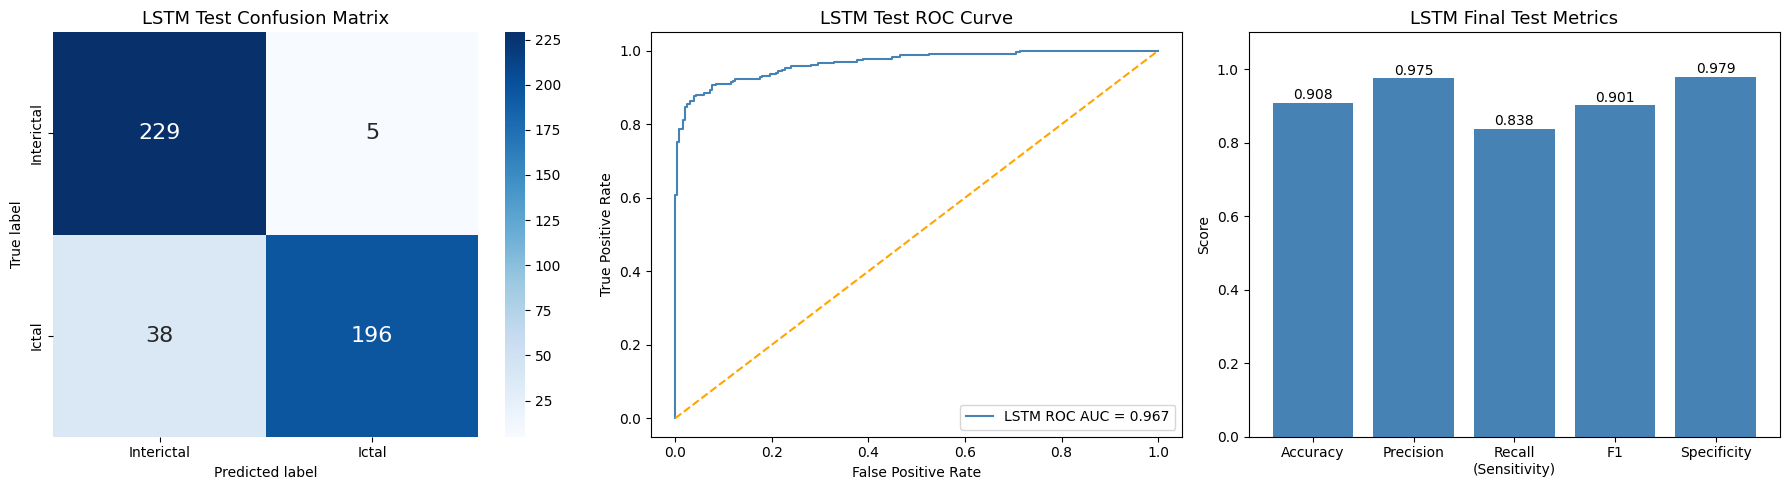

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import numpy as np

# Use your best config arrays
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(best_labels, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Interictal', 'Ictal'],
            yticklabels=['Interictal', 'Ictal'],
            annot_kws={"size": 16})
axes[0].set_title('LSTM Test Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(best_labels, best_probs)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', label=f'LSTM ROC AUC = {roc_auc_val:.3f}')
axes[1].plot([0,1],[0,1],'--', color='orange')
axes[1].set_title('LSTM Test ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Bar chart of key metrics
metrics_names = ['Accuracy', 'Precision', 'Recall\n(Sensitivity)', 'F1', 'Specificity']
metrics_vals  = [
    df.loc[best_idx, 'test_acc'],
    df.loc[best_idx, 'ppv'],
    df.loc[best_idx, 'sensitivity'],
    df.loc[best_idx, 'ictal_f1'],
    df.loc[best_idx, 'specificity'],
]
bars = axes[2].bar(metrics_names, metrics_vals, color='steelblue')
for bar, val in zip(bars, metrics_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10)
axes[2].set_ylim(0, 1.1)
axes[2].set_title('LSTM Final Test Metrics', fontsize=13)
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('lstm_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Optional: save full 5-fold CV results for inspection.
df.to_csv('lstm_5fold_cv_summary.csv', index=False)
df_full.loc[best_idx, '_fold_metrics'].to_csv('lstm_5fold_best_config_folds.csv', index=False)
print("Saved CV summaries:")
print("- lstm_5fold_cv_summary.csv")
print("- lstm_5fold_best_config_folds.csv")


Saved CV summaries:
- lstm_5fold_cv_summary.csv
- lstm_5fold_best_config_folds.csv


In [ ]:

import shap
import lime
import lime.lime_tabular

# ── Build the exact winning model for XAI ─────────────────────────────────────
# Important: this does NOT retrain. It reloads the exact best validation-loss
# weights stored from the winning grid-search row.
best_hidden  = int(best_cfg['hidden_size'])
best_layers  = int(best_cfg['num_layers'])
best_dropout = float(best_cfg['dropout'])

lstm_xai = nn.LSTM(
    input_size=18,
    hidden_size=best_hidden,
    num_layers=best_layers,
    batch_first=True,
    dropout=best_dropout if best_layers > 1 else 0.0
).to(device)

clf_xai = nn.Linear(best_hidden, 1).to(device)

lstm_xai.load_state_dict(df_full.loc[best_idx, '_lstm_state'])
clf_xai.load_state_dict(df_full.loc[best_idx, '_clf_state'])

lstm_xai.eval()
clf_xai.eval()

channel_names = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ'
]

print("Loaded XAI model from saved best grid-search weights.")
print(best_cfg)


Loaded XAI model from saved best grid-search weights.
{'hidden_size': 64.0, 'num_layers': 3.0, 'dropout': 0.5, 'weight_decay': 0.0001, 'lr': 0.001}


Saliency range: 0.0005359108 0.035251297
Saliency percentiles: [0.00053591 0.00150422 0.00314819 0.00939727 0.01718274]


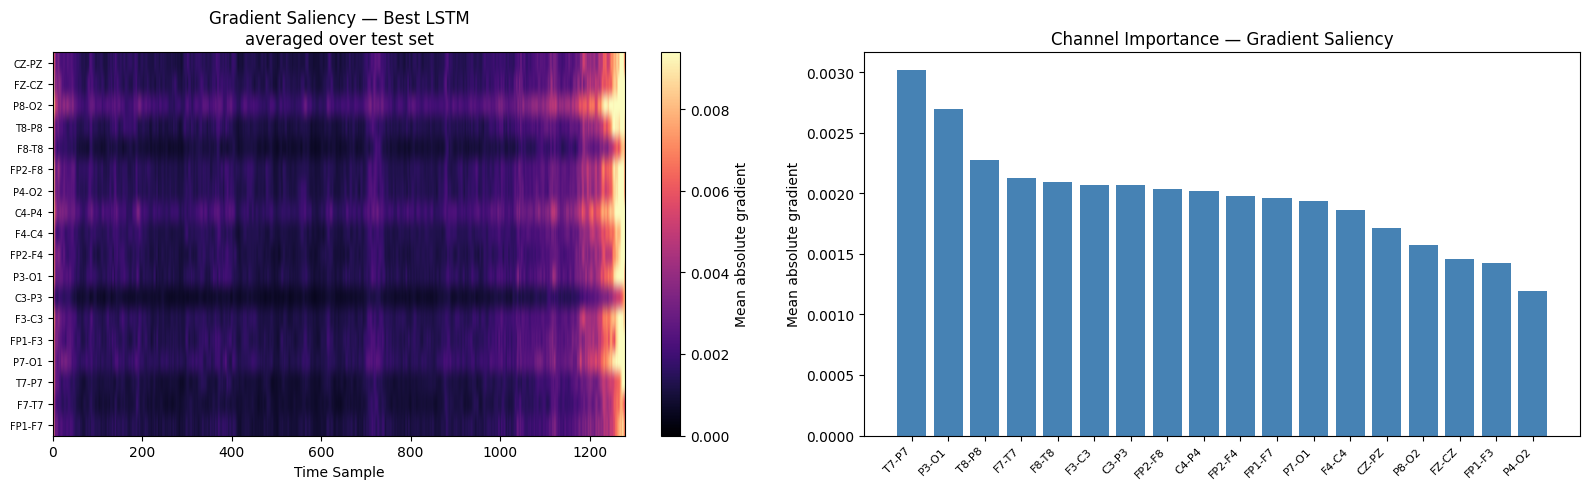

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# 1. GRADIENT SALIENCY
# ═══════════════════════════════════════════════════════════════════════════════
# This keeps the LSTM in eval mode. It disables cuDNN only inside the gradient
# block because some cuDNN RNN backward paths do not support input gradients.

all_saliency = []

lstm_xai.eval()
clf_xai.eval()

with torch.backends.cudnn.flags(enabled=False):
    for X_batch, _ in test_loader:
        for i in range(len(X_batch)):
            X_grad = X_batch[i:i+1].detach().clone().float().to(device)
            X_grad.requires_grad_(True)

            lstm_xai.zero_grad(set_to_none=True)
            clf_xai.zero_grad(set_to_none=True)

            out, _ = lstm_xai(X_grad)
            logit = clf_xai(out[:, -1, :]).squeeze()
            logit.backward()

            sal = X_grad.grad.abs().squeeze(0).detach().cpu().numpy()  # (1280, 18)
            all_saliency.append(sal)

saliency = np.mean(all_saliency, axis=0)          # (1280, 18)
channel_importance = saliency.mean(axis=0)        # (18,)

print("Saliency range:", saliency.min(), saliency.max())
print("Saliency percentiles:", np.percentile(saliency, [0, 50, 90, 99, 99.9]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vmax = np.percentile(saliency, 99)
if vmax <= 0:
    vmax = saliency.max()

im = axes[0].imshow(
    saliency.T,
    aspect='auto',
    cmap='magma',
    vmin=0,
    vmax=vmax,
    extent=[0, 1280, 0, 18]
)
axes[0].set_yticks(np.arange(18) + 0.5)
axes[0].set_yticklabels(channel_names, fontsize=7)
axes[0].set_xlabel('Time Sample')
axes[0].set_title('Gradient Saliency — Best LSTM\naveraged over test set')
plt.colorbar(im, ax=axes[0], label='Mean absolute gradient')

sorted_idx = np.argsort(channel_importance)[::-1]
sorted_vals = channel_importance[sorted_idx]
sorted_names = [channel_names[i] for i in sorted_idx]

axes[1].bar(range(18), sorted_vals, color='steelblue')
axes[1].set_xticks(range(18))
axes[1].set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Channel Importance — Gradient Saliency')
axes[1].set_ylabel('Mean absolute gradient')

plt.tight_layout()
plt.savefig('lstm_saliency.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# 2. SHAP — channel-level Kernel SHAP
# ═══════════════════════════════════════════════════════════════════════════════
# Instead of explaining 23,040 raw time features, this explains 36 interpretable
# features: per-channel mean and standard deviation. This is much more stable
# for Kernel SHAP and avoids the blank/near-zero plot issue from extreme
# under-sampling of the flattened raw signal.

print("Running SHAP on channel-level features...")


def channel_features(X):
    """
    X shape: (N, 1280, 18)
    Returns: (N, 36), containing channel means and channel standard deviations.
    """
    means = X.mean(axis=1)
    stds = X.std(axis=1)
    return np.concatenate([means, stds], axis=1)


# Stored tensors are (N, 18, 1280), while the LSTM expects (N, 1280, 18).
X_train_all = train_data['X'].detach().cpu().numpy().transpose(0, 2, 1)
X_test_all = test_data['X'].detach().cpu().numpy().transpose(0, 2, 1)

X_train_feat = channel_features(X_train_all)
X_test_feat = channel_features(X_test_all)

feature_names = (
    [f"{ch}_mean" for ch in channel_names] +
    [f"{ch}_std" for ch in channel_names]
)


def predict_channel_features(X_feat):
    """
    X_feat shape: (N, 36)
    Returns probabilities with shape (N, 2): [P(interictal), P(ictal)].

    Note: For perturbation-based XAI, the 36-channel summary is mapped back to a
    simple constant-over-time signal using the mean features. The std features
    are still visible to SHAP/LIME, but the current reconstruction uses means
    only. For stronger XAI later, replace this with windowed/channel ablation or
    Captum Integrated Gradients directly on the original time series.
    """
    X_feat = np.asarray(X_feat, dtype=np.float32)
    batch_size = X_feat.shape[0]
    means = X_feat[:, :18]

    X_recon = np.zeros((batch_size, 1280, 18), dtype=np.float32)
    for ch in range(18):
        X_recon[:, :, ch] = means[:, ch][:, None]

    X_tensor = torch.tensor(X_recon, dtype=torch.float32).to(device)

    probs = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), 32):
            xb = X_tensor[i:i+32]
            out, _ = lstm_xai(xb)
            logits = clf_xai(out[:, -1, :]).squeeze(1)
            probs.append(torch.sigmoid(logits).detach().cpu().numpy())

    probs = np.concatenate(probs)
    return np.column_stack([1 - probs, probs])


np.random.seed(42)
bg_size = min(100, len(X_train_feat))
sample_size = min(50, len(X_test_feat))

bg_idx = np.random.choice(len(X_train_feat), size=bg_size, replace=False)
background = X_train_feat[bg_idx]
samples = X_test_feat[:sample_size]

explainer = shap.KernelExplainer(predict_channel_features, background)
shap_values = explainer.shap_values(samples, nsamples=200)

if isinstance(shap_values, list):
    shap_ictal = shap_values[1]
else:
    shap_ictal = shap_values[:, :, 1]

print("SHAP values shape:", np.asarray(shap_ictal).shape)

shap.summary_plot(
    shap_ictal,
    samples,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig('lstm_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: compact channel-level bar chart from mean absolute SHAP values.
shap_importance = np.abs(shap_ictal).mean(axis=0)
order = np.argsort(shap_importance)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_names)), shap_importance[order], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in order], rotation=75, ha='right', fontsize=8)
plt.ylabel('Mean |SHAP value|')
plt.title('SHAP Feature Importance — Channel Mean/Std Features')
plt.tight_layout()
plt.savefig('lstm_shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


Running LIME on channel-level features...


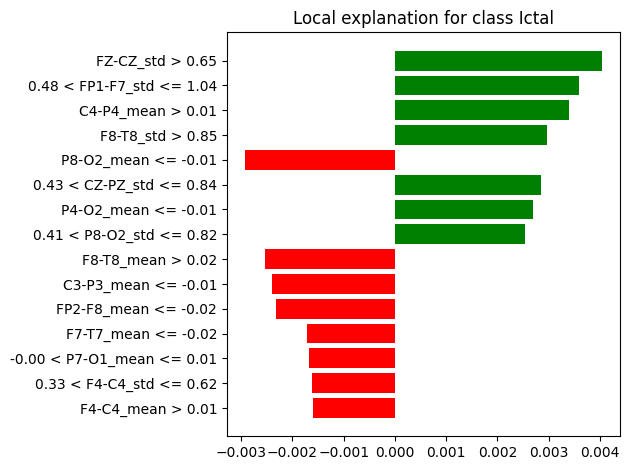

Top LIME features for sample 0
FZ-CZ_std > 0.65: 0.004043
0.48 < FP1-F7_std <= 1.04: 0.003585
C4-P4_mean > 0.01: 0.003393
F8-T8_std > 0.85: 0.002969
P8-O2_mean <= -0.01: -0.002929
0.43 < CZ-PZ_std <= 0.84: 0.002848
P4-O2_mean <= -0.01: 0.002697
0.41 < P8-O2_std <= 0.82: 0.002544
F8-T8_mean > 0.02: -0.002542
C3-P3_mean <= -0.01: -0.002390
FP2-F8_mean <= -0.02: -0.002310
F7-T7_mean <= -0.02: -0.001705
-0.00 < P7-O1_mean <= 0.01: -0.001678
0.33 < F4-C4_std <= 0.62: -0.001610
F4-C4_mean > 0.01: -0.001605


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# 3. LIME — channel-level features
# ═══════════════════════════════════════════════════════════════════════════════
print("Running LIME on channel-level features...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_feat,
    feature_names=feature_names,
    class_names=['Interictal', 'Ictal'],
    mode='classification',
    discretize_continuous=True
)

lime_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_feat[lime_idx],
    predict_fn=predict_channel_features,
    num_features=15,
    num_samples=1000
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig('lstm_lime.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: print the top LIME features for the selected sample.
print("Top LIME features for sample", lime_idx)
for feat, weight in lime_exp.as_list():
    print(f"{feat}: {weight:.6f}")
